# AmphiLocator - EDA Notebook
**ENSIA Machine Learning Project 2025–2026**

### Project overview
This project develops a machine learning system that precisely identifies which of ENSIA's 8 amphitheatres a student is sitting in, using GPS data collected on their phone. The task is a 9-class classification problem (Amphi 1–8 + Outside).

GPS signals inside reinforced-concrete buildings are notoriously noisy — accuracy radii of 15–100 m are common indoors, yet the amphitheatres are only 5–30 m apart. The system therefore relies on feature engineering (averaged coordinates, distances to known centroids, signal variance, device-reported accuracy) rather than raw coordinates alone.

## Exploratory Data Analysis
This notebook covers data loading, label cleaning, class distribution, spatial analysis, GPS quality, separability analysis, a 2-D architectural footprint overlay, and a 3-D building visualisation.

## 1. Setup and Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.patches import Polygon as MplPolygon, FancyBboxPatch
from matplotlib.path import Path
from matplotlib.colors import to_rgba
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global style
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F7F8FC',
    'axes.edgecolor': '#CCCCCC',
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.color': '#E0E0E0',
    'grid.linewidth': 0.6,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'semibold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'legend.framealpha': 0.92,
    'legend.edgecolor': '#CCCCCC',
})

# Colour palette
AMPHI_COLORS = {
    'Amphi 1': '#2563EB',   # blue
    'Amphi 2': '#16A34A',   # green
    'Amphi 3': '#7C3AED',   # violet
    'Amphi 4': '#DC2626',   # red
    'Amphi 5': '#0891B2',   # cyan
    'Amphi 6': '#D97706',   # amber
    'Amphi 7': '#BE185D',   # pink
    'Amphi 8': '#065F46',   # teal
    'Outside': '#6B7280',   # grey
}

print("All imports OK")

All imports OK


## 2. Load Data
We use **gps_data_v2.csv** — the updated dataset collected across all 8 amphitheatres and outdoor areas.

In [3]:
df_raw = pd.read_csv("../data/raw/gps_data_v2.csv")
print(f"Raw shape: {df_raw.shape}")
df_raw.head(5)

Raw shape: (8366, 24)


,id,year,section,user,amphitheatre,module,seat_block,seat_row,seat_column,latitude_mean,...,sample_count,raw_gps_readings,collection_metadata,navigator_context,screen_context,network_information,battery_status,timestamp,created_at,device_info
0,2,3,NaN,NaN,Amphi 3,Manual Selection,Center,3.0,6.0,36.687824,...,0,"[{'latitude': 36.687824, 'longitude': 2.86715,...","{'number_of_readings': 10, 'collection_duratio...","{'platform': 'Win32', 'user_agent': 'Mozilla/5...","{'avail_width': 1536, 'color_depth': 32, 'avai...","{'rtt_ms': 250, 'save_data': False, 'downlink_...","{'is_charging': False, 'battery_level': 0.96}",2026-03-05 07:28:56.580000+00:00,2026-03-05 07:29:01.758897+00:00,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
1,3,3,NaN,NaN,lab 8,Campus-wide Data,NaN,NaN,NaN,36.688127,...,0,"[{'latitude': 36.688126994584465, 'longitude':...","{'number_of_readings': 10, 'collection_duratio...","{'platform': 'Win32', 'user_agent': 'Mozilla/5...","{'avail_width': 1536, 'color_depth': 32, 'avai...","{'rtt_ms': 200, 'save_data': False, 'downlink_...","{'is_charging': False, 'battery_level': 0.76}",2026-03-05 10:00:57.029000+00:00,2026-03-05 10:00:56.927949+00:00,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
2,4,3,NaN,NaN,School entry,Campus-wide Data,NaN,NaN,NaN,36.688729,...,0,"[{'latitude': 36.6886848, 'longitude': 2.86555...","{'number_of_readings': 10, 'collection_duratio...","{'platform': 'Linux armv81', 'user_agent': 'Mo...","{'avail_width': 384, 'color_depth': 24, 'avail...","{'rtt_ms': 100, 'save_data': False, 'downlink_...","{'is_charging': False, 'battery_level': 0.77}",2026-03-05 10:15:16.599000+00:00,2026-03-05 10:15:16.067975+00:00,Mozilla/5.0 (Linux; Android 10; K) AppleWebKit...
3,5,3,NaN,NaN,Amphi 4,Manual Selection,Center,7.0,5.0,36.688630,...,0,"[{'latitude': 36.68863, 'longitude': 2.86675, ...","{'number_of_readings': 10, 'collection_duratio...","{'platform': 'Win32', 'user_agent': 'Mozilla/5...","{'avail_width': 1280, 'color_depth': 32, 'avai...","{'rtt_ms': 100, 'save_data': False, 'downlink_...","{'is_charging': True, 'battery_level': 1}",2026-03-06 15:20:11.927000+00:00,2026-03-06 15:20:12.063691+00:00,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
4,6,3,NaN,NaN,room,Campus-wide Data,NaN,NaN,NaN,36.688630,...,0,"[{'latitude': 36.68863, 'longitude': 2.86675, ...","{'number_of_readings': 10, 'collection_duratio...","{'platform': 'Win32', 'user_agent': 'Mozilla/5...","{'avail_width': 1280, 'color_depth': 32, 'avai...","{'rtt_ms': 100, 'save_data': False, 'downlink_...","{'is_charging': True, 'battery_level': 1}",2026-03-06 15:21:25.994000+00:00,2026-03-06 15:21:26.000699+00:00,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...


## 3. Data Overview

In [4]:
print(f"Rows: {df_raw.shape[0]:,}   Columns: {df_raw.shape[1]}")
df_raw.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])

Rows: 8,366   Columns: 24


,count,mean,std,min,25%,50%,75%,max
id,8366.000000,4197.349988,2415.457646,2.000000,2106.250000,4197.500000,6288.750000,8380.000000
year,8366.000000,1.969400,0.960684,1.000000,1.000000,2.000000,3.000000,5.000000
section,0.000000,nan,nan,nan,nan,nan,nan,nan
seat_row,7131.000000,4.321974,2.748524,1.000000,2.000000,4.000000,6.000000,10.000000
seat_column,7131.000000,4.118356,2.119108,1.000000,3.000000,4.000000,5.000000,9.000000
latitude_mean,8366.000000,36.688075,0.020138,34.854788,36.688328,36.688346,36.688366,36.753994
longitude_mean,8366.000000,2.866021,0.050750,-1.731618,2.866181,2.866487,2.866665,3.433505
accuracy_mean,8366.000000,40.683556,285.306787,3.000000,13.899730,20.000000,26.355000,24367.111310
gps_variance,8366.000000,0.613382,30.130006,0.000000,0.000000,0.000000,0.000000,2620.859617
sample_count,8366.000000,0.997131,0.489450,0.000000,1.000000,1.000000,1.000000,45.000000


In [5]:
df_raw['timestamp']  = pd.to_datetime(df_raw['timestamp'],  format='mixed', utc=True)
df_raw['created_at'] = pd.to_datetime(df_raw['created_at'], format='mixed', utc=True)
df_raw['is_outside'] = df_raw['is_outside'].astype(bool)
print("Timestamp range:", df_raw['timestamp'].min().date(), "→", df_raw['timestamp'].max().date())
print(f"Collection span: {(df_raw['timestamp'].max() - df_raw['timestamp'].min()).days} days")

Timestamp range: 2026-03-05 → 2026-04-20
Collection span: 46 days


In [6]:
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing.to_string())

Columns with missing values:
section        8366
user           7499
seat_block     1235
seat_column    1235
seat_row       1235
module          867
device_info     867


In [7]:
df_no_id = df_raw.drop(columns=['id'])
df_duplicates = df_no_id[df_no_id.duplicated(keep=False)]
duplicates_count = df_duplicates.shape[0]

print(f"Duplicate rows (without id): {duplicates_count:,}")

Duplicate rows (without id): 6


In [60]:
df["is_outside"].value_counts()

is_outside
False    6369
True      846
Name: count, dtype: int64

**Notes on v2 data:**
- `section` and `user` remain mostly absent - not used as features.
- `seat_block / seat_row / seat_column` are missing for the outside / campus-wide rows (no seat was assigned). These columns are only needed for the optional seat-zone extension.
- Core GPS columns (`latitude_mean`, `longitude_mean`, `accuracy_mean`, `gps_variance`) are fully populated — good.

## 4. Label Cleaning

The raw `amphitheatre` column contains 32+ distinct strings — typos, test entries, informal names, and genuine outside locations. We canonicalise everything into 9 classes: **Amphi 1–8 + Outside**.

In [9]:
print("Raw amphitheatre values:")
print(df_raw['amphitheatre'].value_counts().to_string())

Raw amphitheatre values:
amphitheatre
Amphi 2                2565
Amphi 5                1227
Amphi 8                 989
Amphi 6                 774
Amphi 4                 741
Outside                 658
Amphi 1                 604
Amphi 3                 318
Amphi 7                 122
Nasro                   100
Mdpres end tarek         46
maalma3                  33
Dorms                    21
SkillnTell Spot          20
Salle d'études           20
Amphi 3 door 2           10
nasro                    10
Hfgnffn                  10
study room               10
Amphi 3 door 1           10
Hall                     10
AMPHI8                   10
tuto23                   10
Lab 8                    10
Salle d’études           10
Spot                     10
In front of amphi 8      10
outside                   2
lab 8                     1
end tarek                 1
dorm                      1
room                      1
mazalni end tarek         1
School entry              1


In [10]:
\
AMPHI_MAP = {
    'Amphi 1': 'Amphi 1', 'Amphi 2': 'Amphi 2', 'Amphi 3': 'Amphi 3',
    'Amphi 3 door 1': 'Amphi 3', 'Amphi 3 door 2': 'Amphi 3',
    'Amphi 4': 'Amphi 4', 'Amphi 5': 'Amphi 5', 'Amphi 6': 'Amphi 6',
    'Amphi 7': 'Amphi 7', 'Amphi 8': 'Amphi 8', 'AMPHI8': 'Amphi 8',
    'Outside': 'Outside', 'outside': 'Outside',
    'Nasro': 'Outside', 'nasro': 'Outside', 'nasro ': 'Outside',
    'Dorms': 'Outside', 'Hall': 'Outside', 'maalma3': 'Outside',
    'School entry': 'Outside', 'lab 8': 'Outside', 'Lab 8': 'Outside',
    'room': 'Outside', 'study room': 'Outside',
    'In front of amphi 8': 'Outside',
    "Salle d\u2019\u00e9tudes": 'Outside', "Salle d'études": 'Outside',
    'SkillnTell Spot': 'Outside', 'SkillnTell Spot ': 'Outside',
    'Spot': 'Outside', 'Spot ': 'Outside',
}
DROP_LABELS = {'Mdpres end tarek', 'end tarek', 'mazalni end tarek',
               'Hfgnffn', 'tuto23', 'dorm'}

df = df_raw.copy()
df['label'] = df['amphitheatre'].map(AMPHI_MAP)
n_junk = df['label'].isna().sum()
print(f"Rows with unmappable/junk labels dropped: {n_junk}")
df = df[df['label'].notna()].copy()

geo_mask = (
    (df['latitude_mean']  >= 36.60) & (df['latitude_mean']  <= 36.76) &
    (df['longitude_mean'] >= 2.85)  & (df['longitude_mean'] <= 2.90)
)
print(f"Rows removed for off-campus GPS coords: {(~geo_mask).sum()}")
df = df[geo_mask].copy()

print(f"\nClean dataset shape: {df.shape}")
print("\nFinal label distribution:")
print(df['label'].value_counts().to_string())

Rows with unmappable/junk labels dropped: 89
Rows removed for off-campus GPS coords: 3

Clean dataset shape: (8274, 25)

Final label distribution:
label
Amphi 2    2564
Amphi 5    1226
Amphi 8     999
Outside     926
Amphi 6     774
Amphi 4     741
Amphi 1     604
Amphi 3     318
Amphi 7     122


## 5. Class Distribution

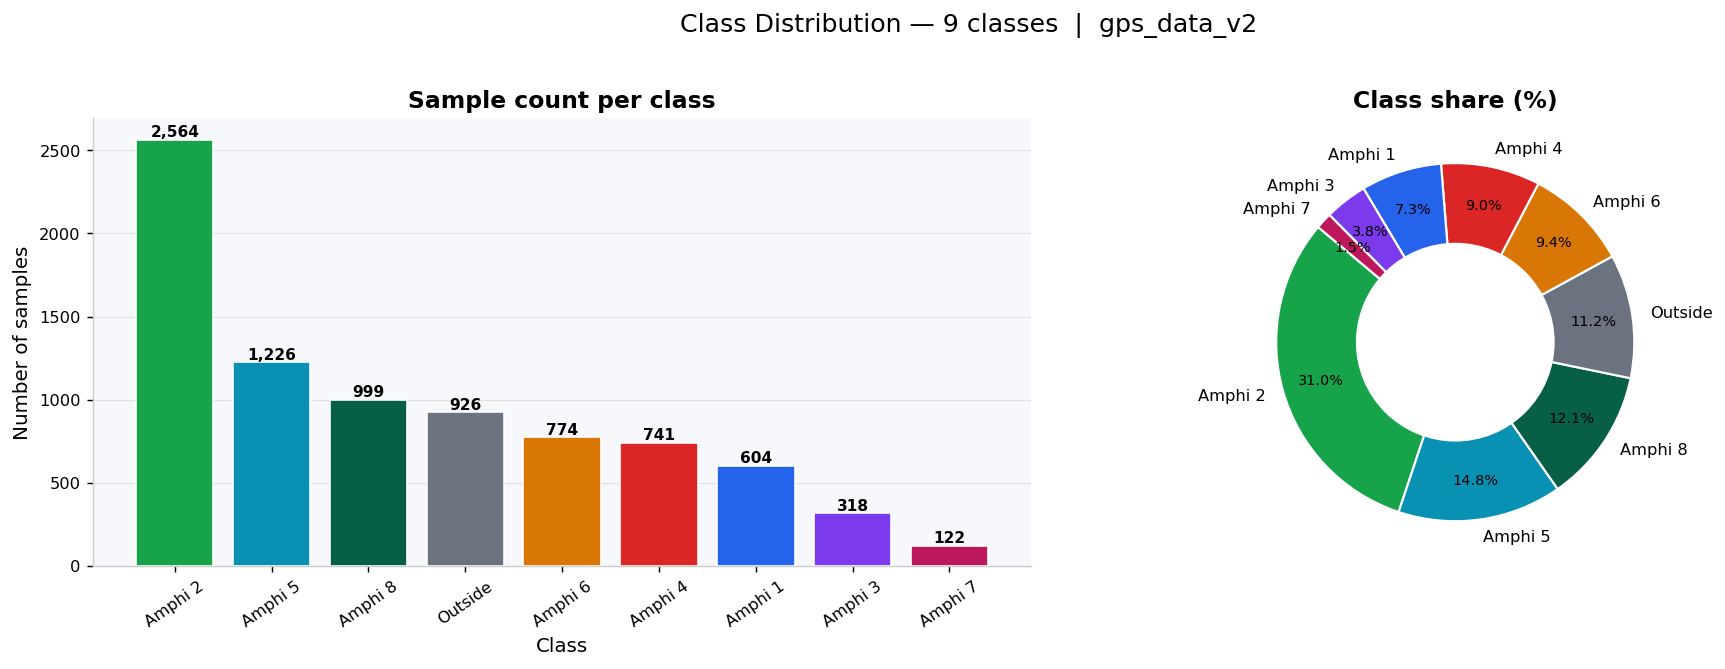

In [ ]:
order  = df['label'].value_counts().index.tolist()
counts = df['label'].value_counts()
colors = [AMPHI_COLORS[l] for l in order]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
bars = axes[0].bar(order, counts.values, color=colors,
                   edgecolor='white', linewidth=0.9, zorder=3)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of samples')
axes[0].set_title('Sample count per class')
axes[0].tick_params(axis='x', rotation=35)
axes[0].yaxis.grid(True, zorder=0)
axes[0].set_axisbelow(True)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 18,
                 f'{v:,}', ha='center', fontsize=8.5, fontweight='semibold')

# Donut chart 
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=order, autopct='%1.1f%%',
    colors=colors, startangle=140, pctdistance=0.78,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2})
for at in autotexts:
    at.set_fontsize(8)
# punch a hole to make it a donut
centre = plt.Circle((0, 0), 0.55, color='white')
axes[1].add_artist(centre)
axes[1].set_title('Class share (%)')

plt.suptitle('Class Distribution — 9 classes  |  gps_data_v2', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/class_distribution.png', bbox_inches='tight')
plt.show()

## 6. GPS Spatial Analysis

Can raw lat/lon coordinates alone separate the 8 amphitheatres? This section explores the spatial distributions and identifies overlap zones.

In [ ]:
# Per-class GPS centroids 
centroids = (df[df['label'] != 'Outside']
             .groupby('label')[['latitude_mean', 'longitude_mean']]
             .mean()
             .rename(columns={'latitude_mean': 'centroid_lat',
                              'longitude_mean': 'centroid_lon'}))
print("GPS centroids (decimal degrees):")
print(centroids.round(6).to_string())

GPS centroids (decimal degrees):
         centroid_lat  centroid_lon
label                              
Amphi 1     36.688350      2.866760
Amphi 2     36.688318      2.866539
Amphi 3     36.688308      2.866222
Amphi 4     36.688303      2.866123
Amphi 5     36.688358      2.866695
Amphi 6     36.688370      2.866409
Amphi 7     36.688380      2.866311
Amphi 8     36.688323      2.866134


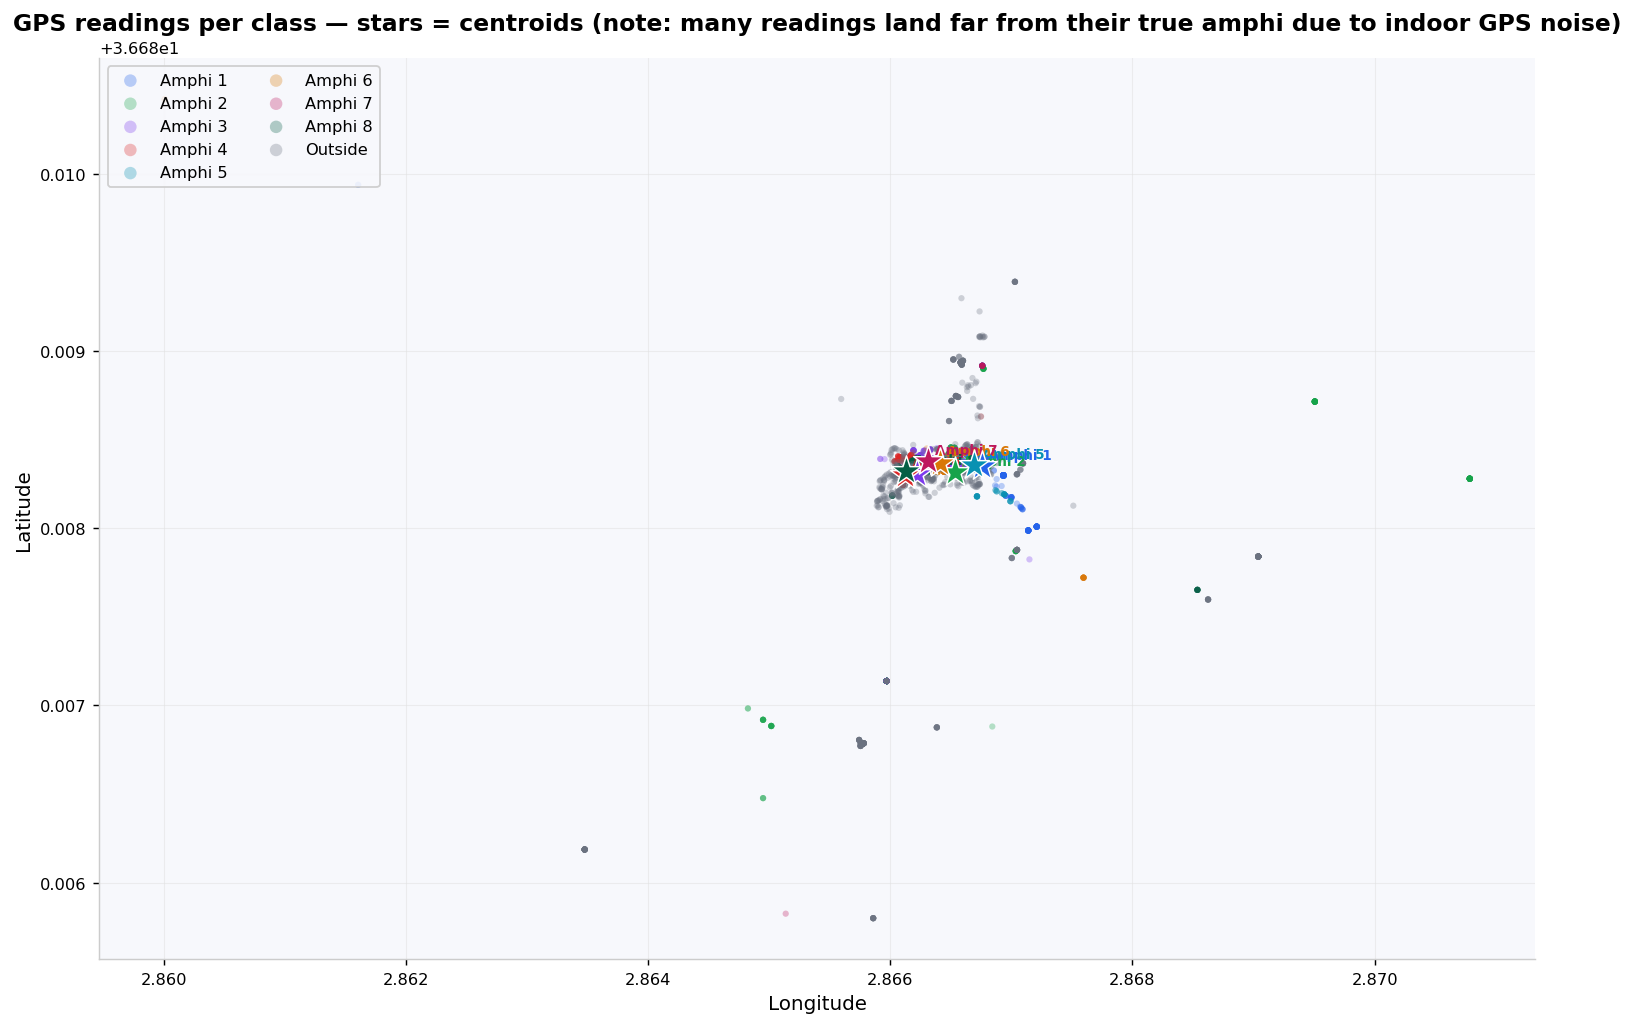

In [ ]:
# All-classes scatter with convex-hull KDE contours 
fig, ax = plt.subplots(figsize=(12, 8))

label_order = sorted(df['label'].unique())
for lbl in label_order:
    sub = df[df['label'] == lbl]
    c   = AMPHI_COLORS[lbl]
    ax.scatter(sub['longitude_mean'], sub['latitude_mean'],
               color=c, alpha=0.30, s=12, label=lbl, edgecolors='none', zorder=3)

# Centroid markers
for lbl, row in centroids.iterrows():
    ax.scatter(row['centroid_lon'], row['centroid_lat'],
               marker='*', s=300, color=AMPHI_COLORS[lbl],
               edgecolor='white', linewidth=0.8, zorder=7)
    ax.annotate(lbl, (row['centroid_lon'], row['centroid_lat']),
                xytext=(4, 4), textcoords='offset points',
                fontsize=7.5, color=AMPHI_COLORS[lbl], fontweight='bold')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('GPS readings per class — stars = centroids ' '(note: many readings land far from their true amphi due to indoor GPS noise)')
ax.grid(True, alpha=0.5)
ax.legend(markerscale=2, ncol=2, loc='upper left', framealpha=0.92)
plt.tight_layout()
plt.savefig('../results/gps_scatter_all.png', bbox_inches='tight')
plt.show()

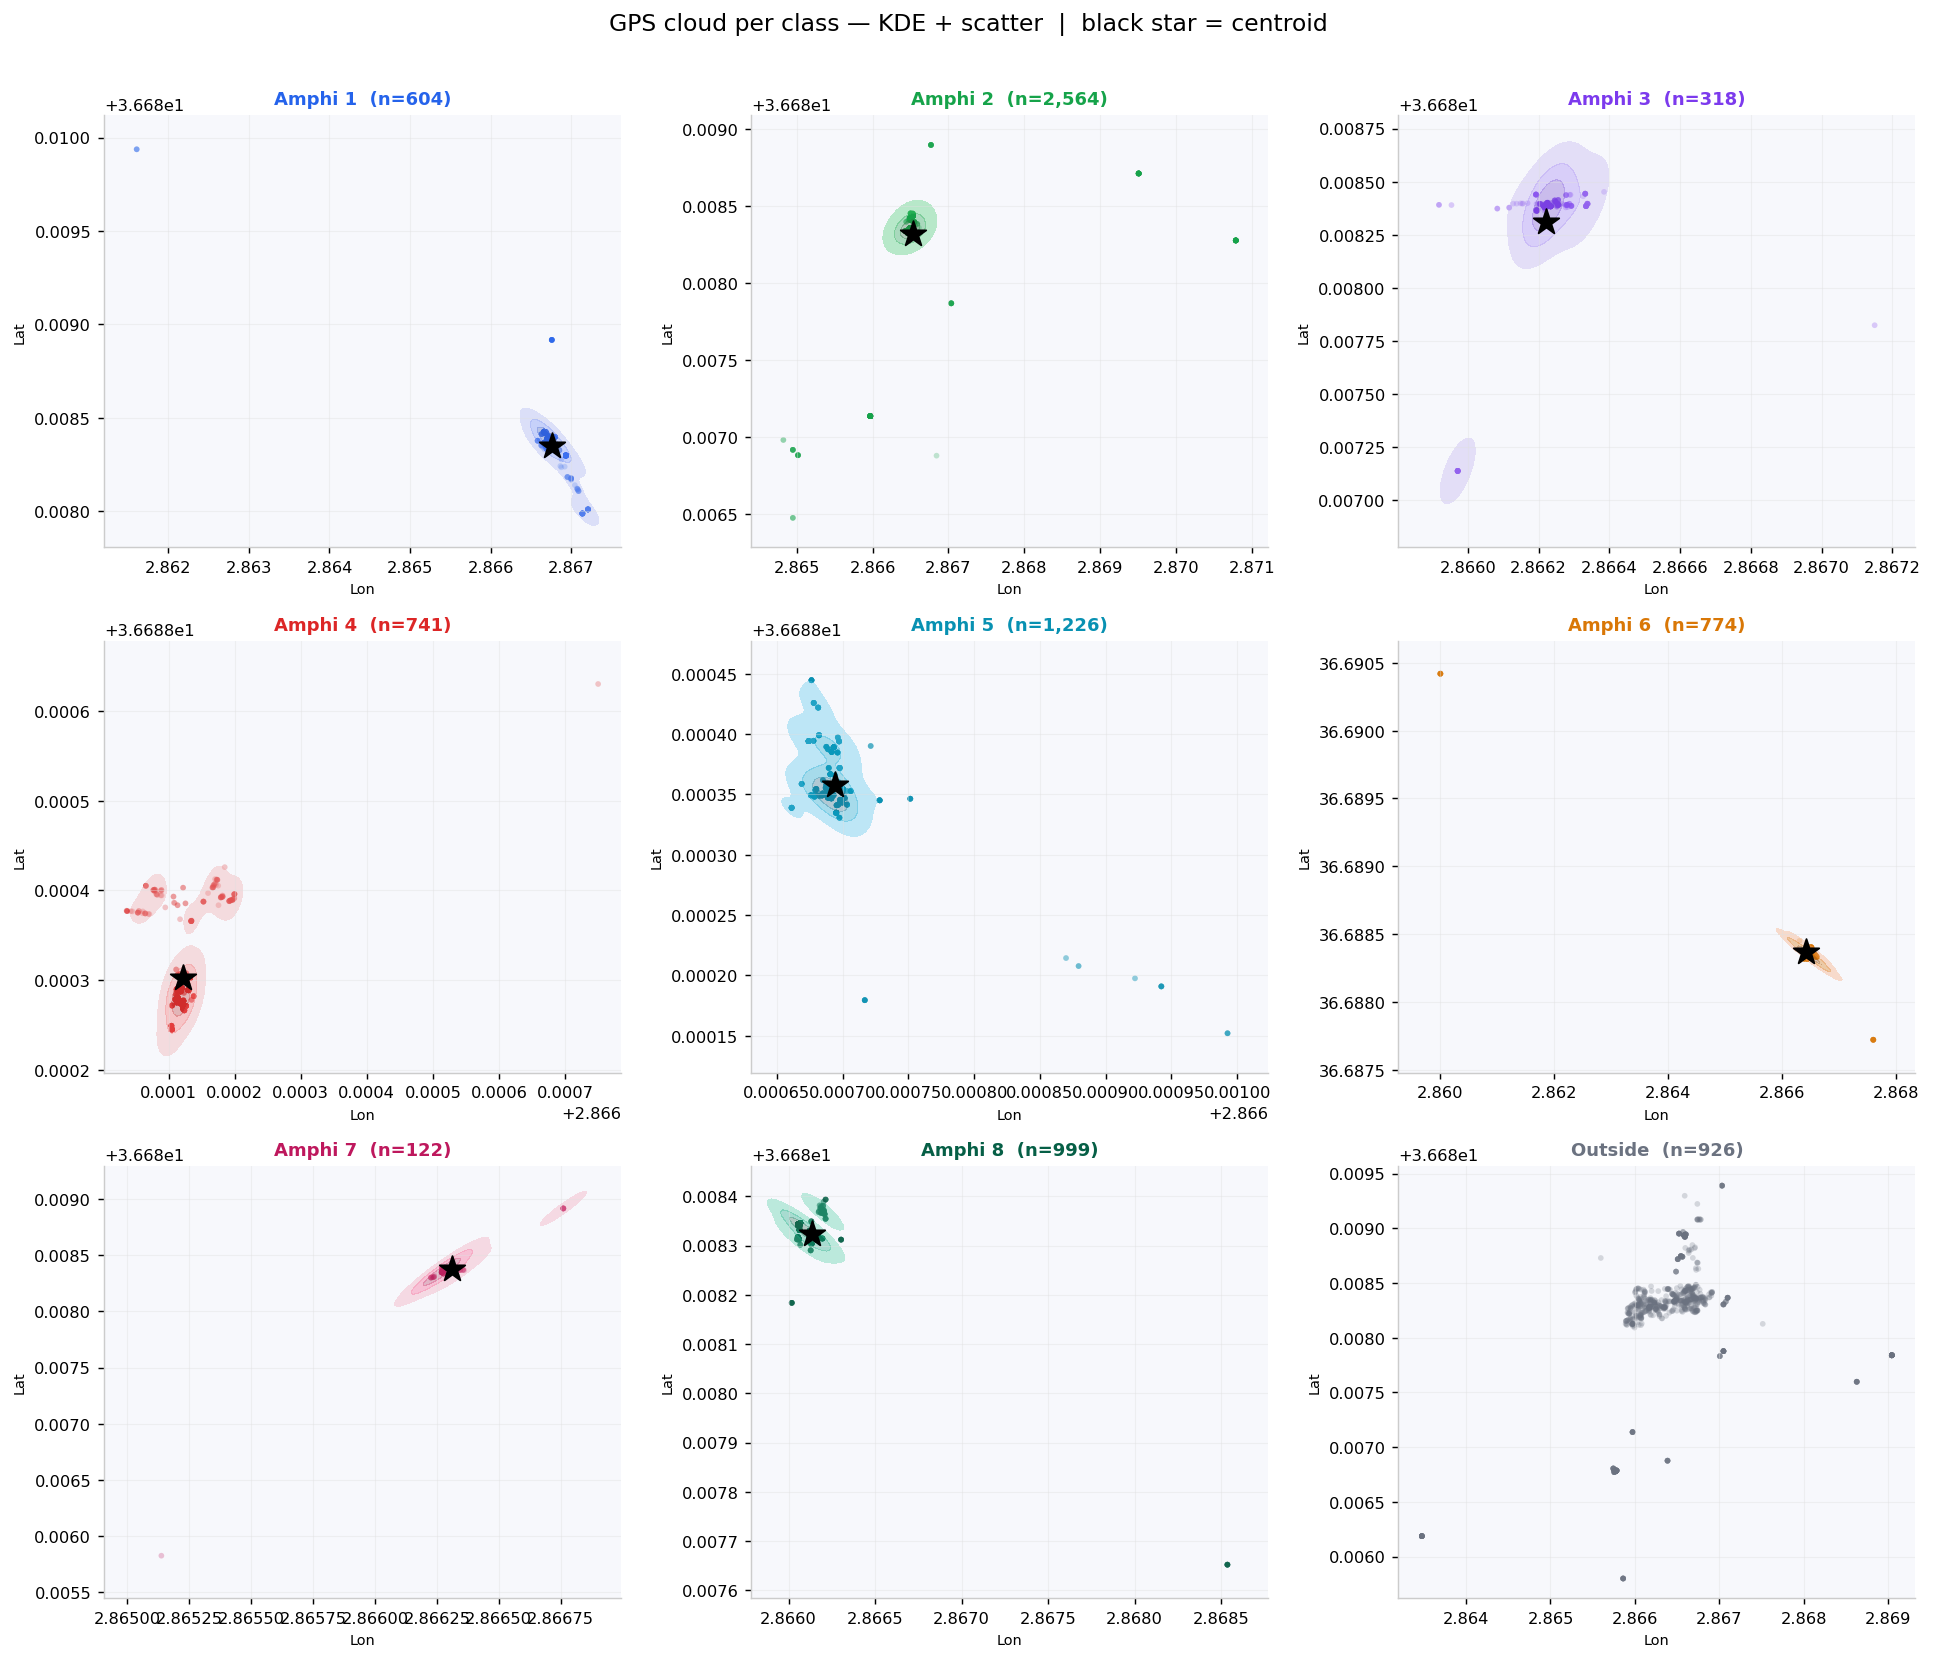

In [ ]:
# Per-class facets with KDE overlay 
label_order_amphi = [f'Amphi {i}' for i in range(1, 9)] + ['Outside']
cols = 3
rows_n = (len(label_order_amphi) + cols - 1) // cols

fig, axes = plt.subplots(rows_n, cols, figsize=(15, rows_n * 4.2))
axes = axes.flatten()

for i, lbl in enumerate(label_order_amphi):
    sub = df[df['label'] == lbl]
    c   = AMPHI_COLORS[lbl]
    axes[i].scatter(sub['longitude_mean'], sub['latitude_mean'],
                    color=c, alpha=0.25, s=10, edgecolors='none')
    if lbl != 'Outside' and len(sub) > 15:
        try:
            sns.kdeplot(data=sub, x='longitude_mean', y='latitude_mean',
                        fill=True, thresh=0.1, levels=4,
                        color=c, alpha=0.35, ax=axes[i])
        except Exception:
            pass
    if lbl in centroids.index:
        axes[i].scatter(centroids.loc[lbl,'centroid_lon'],
                        centroids.loc[lbl,'centroid_lat'],
                        marker='*', s=220, color='black', zorder=6)
    n_pts = len(sub)
    axes[i].set_title(f'{lbl}  (n={n_pts:,})', fontsize=10, fontweight='semibold',
                      color=c)
    axes[i].set_xlabel('Lon', fontsize=8)
    axes[i].set_ylabel('Lat', fontsize=8)
    axes[i].grid(True, alpha=0.4)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('GPS cloud per class — KDE + scatter  |  black star = centroid',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/gps_facets.png', bbox_inches='tight')
plt.show()

**Observations:**
- Most amphitheatres form clusters, but cluster spread often exceeds the physical room size - typical for indoor GPS.
- Amphi 2 has the largest spread, confirming noisy/corridor readings.
- Amphi 4 and 5 remain the tightest clusters (std < 4 m).
- Significant overlap exists between adjacent pairs (1/5, 2/6, 3/7, 4/8) — **the 3-D model in Section 10 shows exactly why: they are stacked floors of the same building column**.

## 7. GPS Quality & Noise Analysis

`accuracy_mean` is the radius (metres) within which the device estimates its true position lies. `gps_variance` captures how much the 10-second burst of readings moved around.

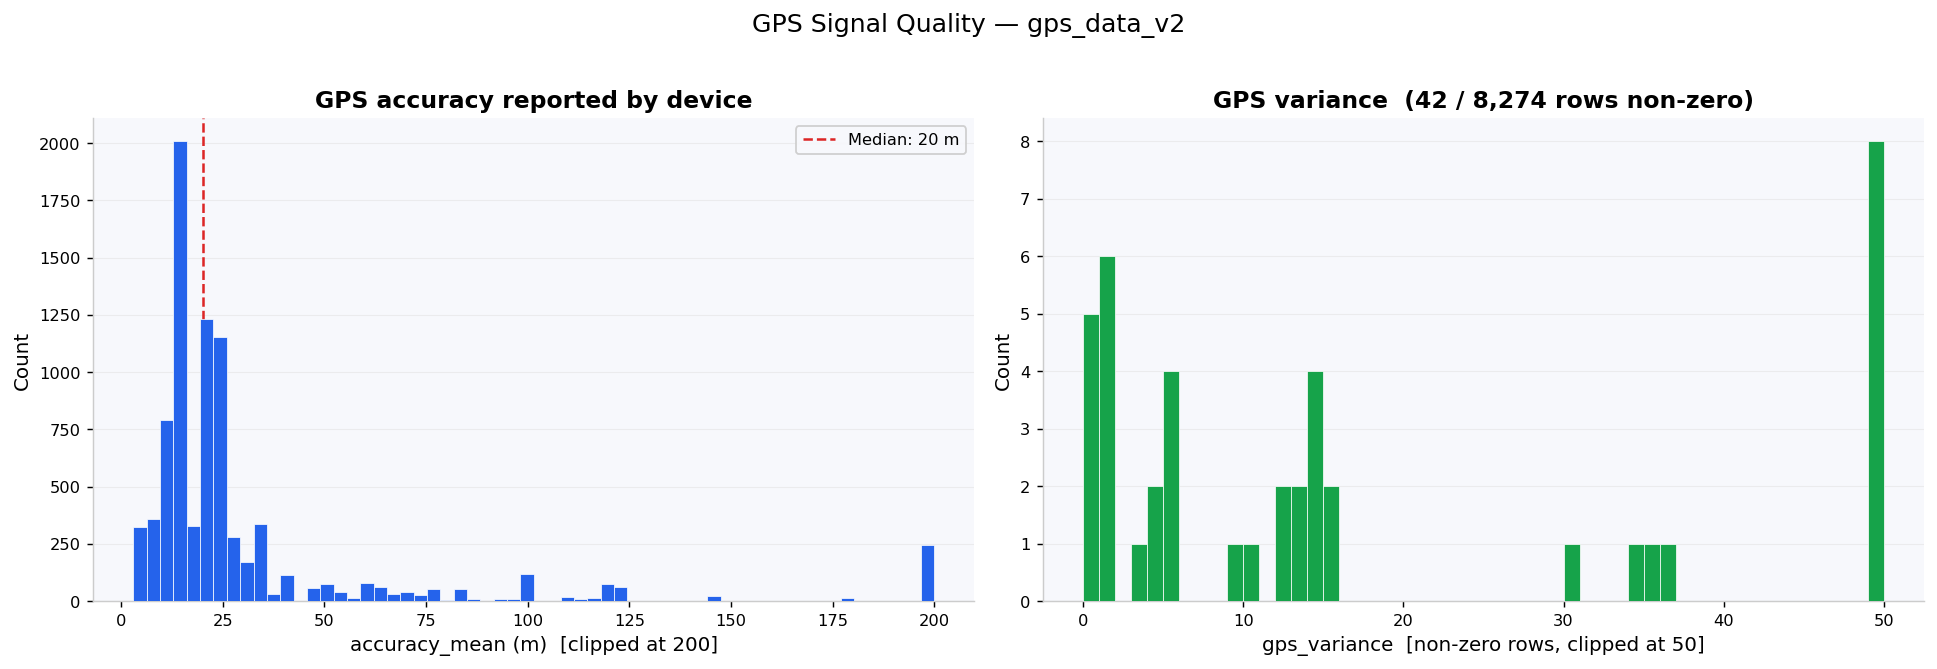

Median accuracy : 20.0 m
90th percentile : 65.3 m
99th percentile : 317.1 m


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# accuracy histogram
acc = df['accuracy_mean'].clip(upper=200)
axes[0].hist(acc, bins=60, color='#2563EB', edgecolor='white', linewidth=0.4, zorder=3)
med = df['accuracy_mean'].median()
axes[0].axvline(med, color='#DC2626', linestyle='--', linewidth=1.4,
                label=f'Median: {med:.0f} m')
axes[0].set_xlabel('accuracy_mean (m)  [clipped at 200]')
axes[0].set_ylabel('Count')
axes[0].set_title('GPS accuracy reported by device')
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.5)

# variance histogram
var_nz = df[df['gps_variance'] > 0]['gps_variance'].clip(upper=50)
axes[1].hist(var_nz, bins=50, color='#16A34A', edgecolor='white', linewidth=0.4, zorder=3)
axes[1].set_xlabel('gps_variance  [non-zero rows, clipped at 50]')
axes[1].set_ylabel('Count')
axes[1].set_title(f'GPS variance  ({(df["gps_variance"]>0).sum():,} / {len(df):,} rows non-zero)')
axes[1].grid(True, axis='y', alpha=0.5)

plt.suptitle('GPS Signal Quality — gps_data_v2', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../results/gps_quality_histograms.png', bbox_inches='tight')
plt.show()
print(f"Median accuracy : {df['accuracy_mean'].median():.1f} m")
print(f"90th percentile : {df['accuracy_mean'].quantile(0.9):.1f} m")
print(f"99th percentile : {df['accuracy_mean'].quantile(0.99):.1f} m")

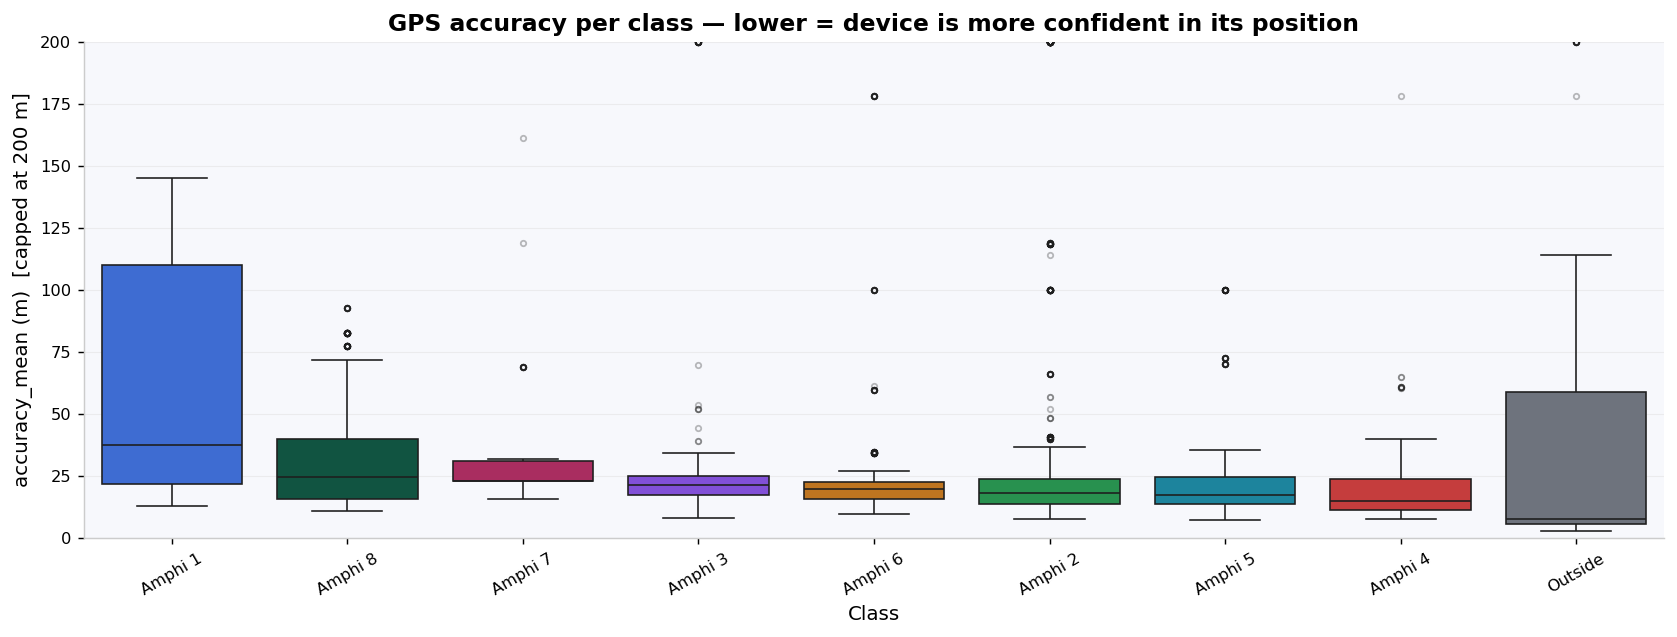

In [16]:
fig, ax = plt.subplots(figsize=(13, 5))
order_acc = (df.groupby('label')['accuracy_mean']
               .median().sort_values(ascending=False).index.tolist())
palette_acc = [AMPHI_COLORS[l] for l in order_acc]

sns.boxplot(data=df, x='label', y='accuracy_mean', order=order_acc,
            palette=palette_acc, fliersize=2, linewidth=0.9, ax=ax,
            flierprops={'alpha': 0.3, 'markersize': 3})
ax.set_ylim(0, 200)
ax.set_xlabel('Class')
ax.set_ylabel('accuracy_mean (m)  [capped at 200 m]')
ax.set_title('GPS accuracy per class — lower = device is more confident in its position')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.grid(True, alpha=0.5, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('../results/accuracy_by_class.png', bbox_inches='tight')
plt.show()

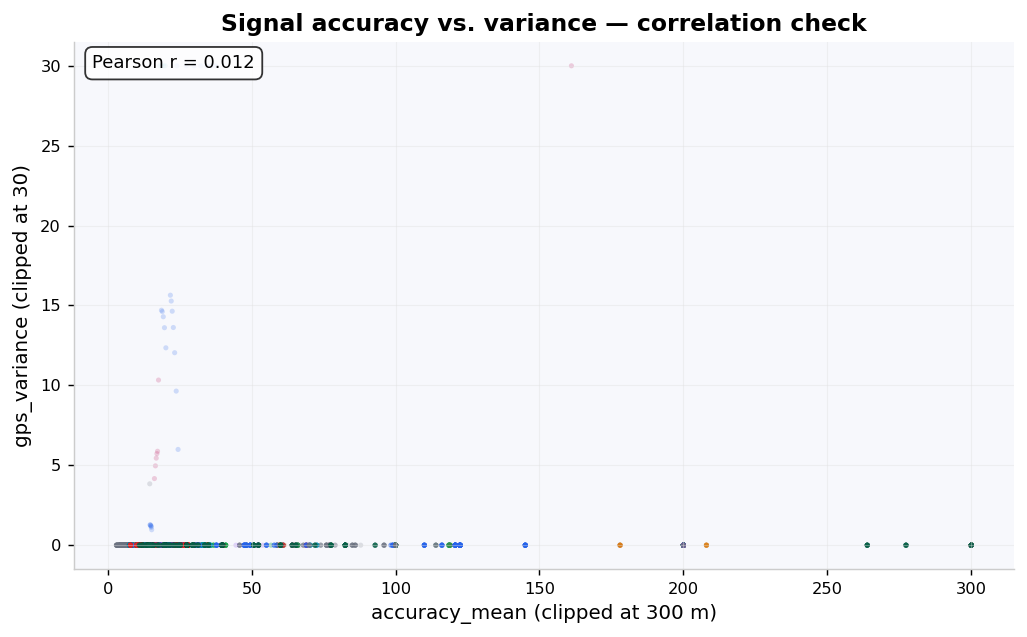

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(df['accuracy_mean'].clip(upper=300),
                df['gps_variance'].clip(upper=30),
                c=[AMPHI_COLORS[l] for l in df['label']],
                alpha=0.20, s=8, edgecolors='none')
ax.set_xlabel('accuracy_mean (clipped at 300 m)')
ax.set_ylabel('gps_variance (clipped at 30)')
ax.set_title('Signal accuracy vs. variance — correlation check')
corr = df['accuracy_mean'].corr(df['gps_variance'])
ax.text(0.02, 0.95, f'Pearson r = {corr:.3f}',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('../results/accuracy_vs_variance.png', bbox_inches='tight')
plt.show()

## 8. Overlap & Separability Analysis

How far apart are the amphitheatre centroids? This tells us directly how hard the classification problem is for a GPS-only model.

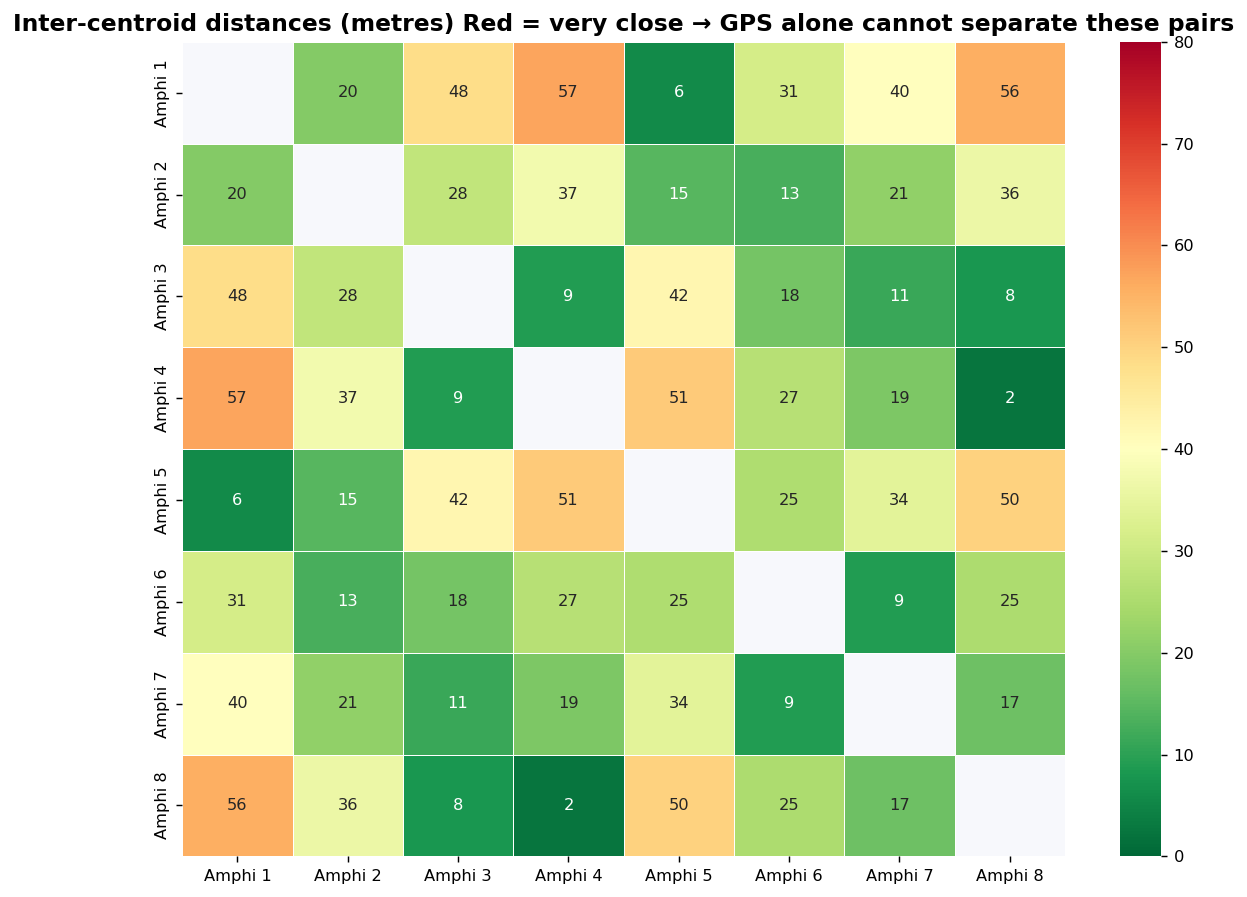

In [18]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6_371_000
    phi1, phi2 = radians(lat1), radians(lat2)
    a = sin((phi2-phi1)/2)**2 + cos(phi1)*cos(phi2)*sin((radians(lon2-lon1))/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

labels_c    = centroids.index.tolist()
dist_matrix = pd.DataFrame(index=labels_c, columns=labels_c, dtype=float)
for l1 in labels_c:
    for l2 in labels_c:
        dist_matrix.loc[l1, l2] = haversine(
            centroids.loc[l1,'centroid_lat'], centroids.loc[l1,'centroid_lon'],
            centroids.loc[l2,'centroid_lat'], centroids.loc[l2,'centroid_lon'])

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.eye(len(labels_c), dtype=bool)
sns.heatmap(dist_matrix.astype(float), annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.5, mask=mask, ax=ax, annot_kws={'size': 9},
            vmin=0, vmax=80)
ax.set_title('Inter-centroid distances (metres) ' 'Red = very close → GPS alone cannot separate these pairs')
plt.tight_layout()
plt.savefig('../results/centroid_distance_heatmap.png', bbox_inches='tight')
plt.show()

**Key takeaway:** Multiple centroid pairs are < 15 m apart — comfortably within the indoor GPS accuracy margin of ~20 m. The model **cannot** rely on raw lat/lon alone. Engineered features — distance to each centroid, GPS accuracy, variance, and potentially Wi-Fi/cell signal — are essential.

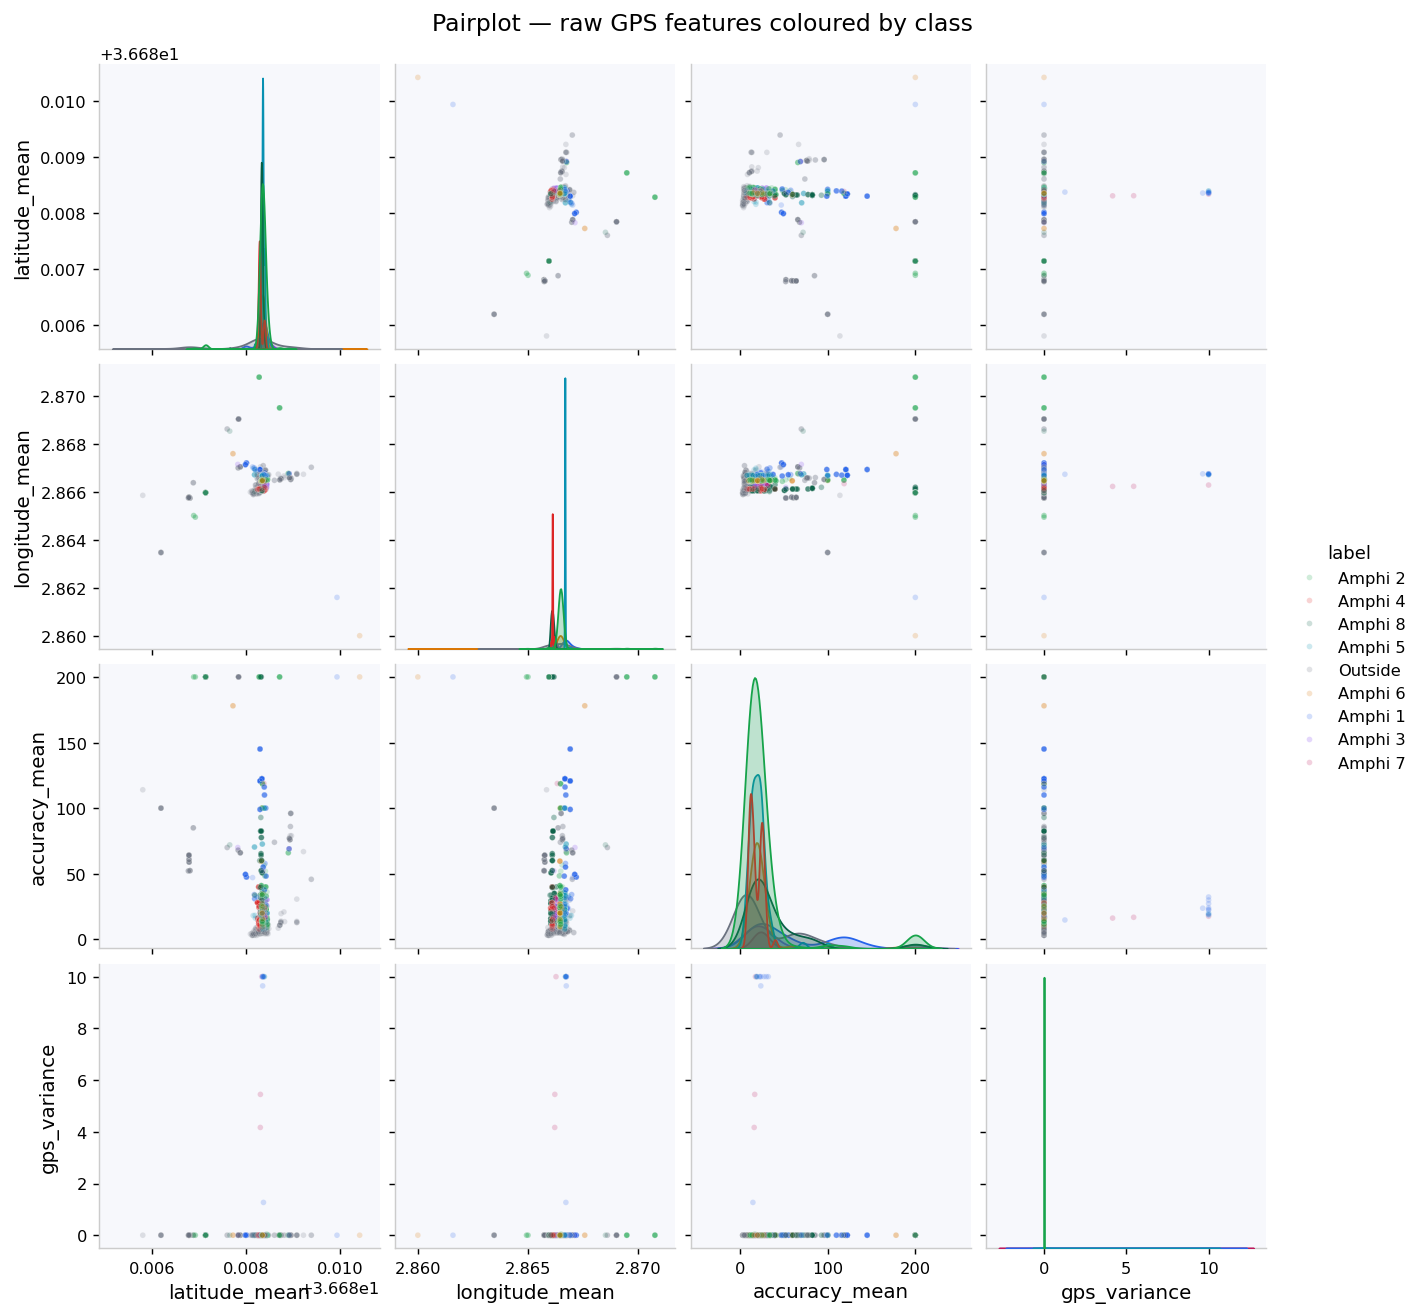

In [19]:
gps_cols = ['latitude_mean', 'longitude_mean', 'accuracy_mean', 'gps_variance']
plot_df  = df[gps_cols + ['label']].copy()
plot_df['accuracy_mean'] = plot_df['accuracy_mean'].clip(upper=200)
plot_df['gps_variance']  = plot_df['gps_variance'].clip(upper=10)
sample = plot_df.sample(min(2500, len(plot_df)), random_state=42)
palette_pp = {l: AMPHI_COLORS[l] for l in sample['label'].unique()}
g = sns.pairplot(sample, hue='label', vars=gps_cols,
                 plot_kws={'alpha': 0.20, 's': 10},
                 diag_kind='kde', palette=palette_pp)
g.fig.suptitle('Pairplot — raw GPS features coloured by class', y=1.01, fontsize=13)
plt.savefig('../results/pairplot_raw.png', bbox_inches='tight')
plt.show()

## 9. Amphitheatre Footprint Map (2D)

This plot shows the **true architectural layout** of the ENSIA amphitheatre block as seen from above, with all GPS readings overlaid.

The building has 4 room-columns side by side. Each column contains **two vertically stacked rooms** — one on each floor:

| Column (West → East) | Floor 1 (ground) | Floor 2 (upper) |
|---|---|---|
| 1 | Amphi 4 | Amphi 8 |
| 2 | Amphi 3 | Amphi 7 |
| 3 | Amphi 2 | Amphi 6 |
| 4 | Amphi 1 | Amphi 5 |

Because GPS is a 2-D signal (lat/lon only), the two floors of each column share the **exact same footprint on this map**. That is the fundamental challenge: the model must learn to separate them using non-spatial signals.

> **Important:** the GPS readings shown do **not** reflect where the rooms physically are — they reflect where the phone *thought* it was, after the signal passed through the roof. The footprints are drawn from real architectural knowledge of the building, not from the GPS data.

In [ ]:
# Order: Amphi 4/8 (westmost) → Amphi 3/7 → Amphi 2/6 → Amphi 1/5 

FOOTPRINTS = {
    'Amphi 4/8': np.array([
        (2.86588, 36.68800), (2.86602, 36.68800),
        (2.86605, 36.68818), (2.86590, 36.68817),
    ]),
    'Amphi 3/7': np.array([
        (2.86610, 36.68800), (2.86625, 36.68800),
        (2.86628, 36.68819), (2.86613, 36.68818),
    ]),
    'Amphi 2/6': np.array([
        (2.86633, 36.68800), (2.86650, 36.68800),
        (2.86655, 36.68821), (2.86638, 36.68820),
    ]),
    'Amphi 1/5': np.array([
        (2.86658, 36.68805), (2.86675, 36.68806),
        (2.86680, 36.68825), (2.86663, 36.68823),
    ]),
}

FP_FILL  = {'Amphi 1/5': '#BFDBFE', 'Amphi 2/6': '#BBF7D0',
            'Amphi 3/7': '#DDD6FE', 'Amphi 4/8': '#FECACA'}
FP_EDGE  = {'Amphi 1/5': '#1D4ED8', 'Amphi 2/6': '#15803D',
            'Amphi 3/7': '#6D28D9', 'Amphi 4/8': '#B91C1C'}
FP_TEXT  = FP_EDGE   # label colour = edge colour

GPS_COLOR_2D = {lbl: AMPHI_COLORS[lbl] for lbl in AMPHI_COLORS}

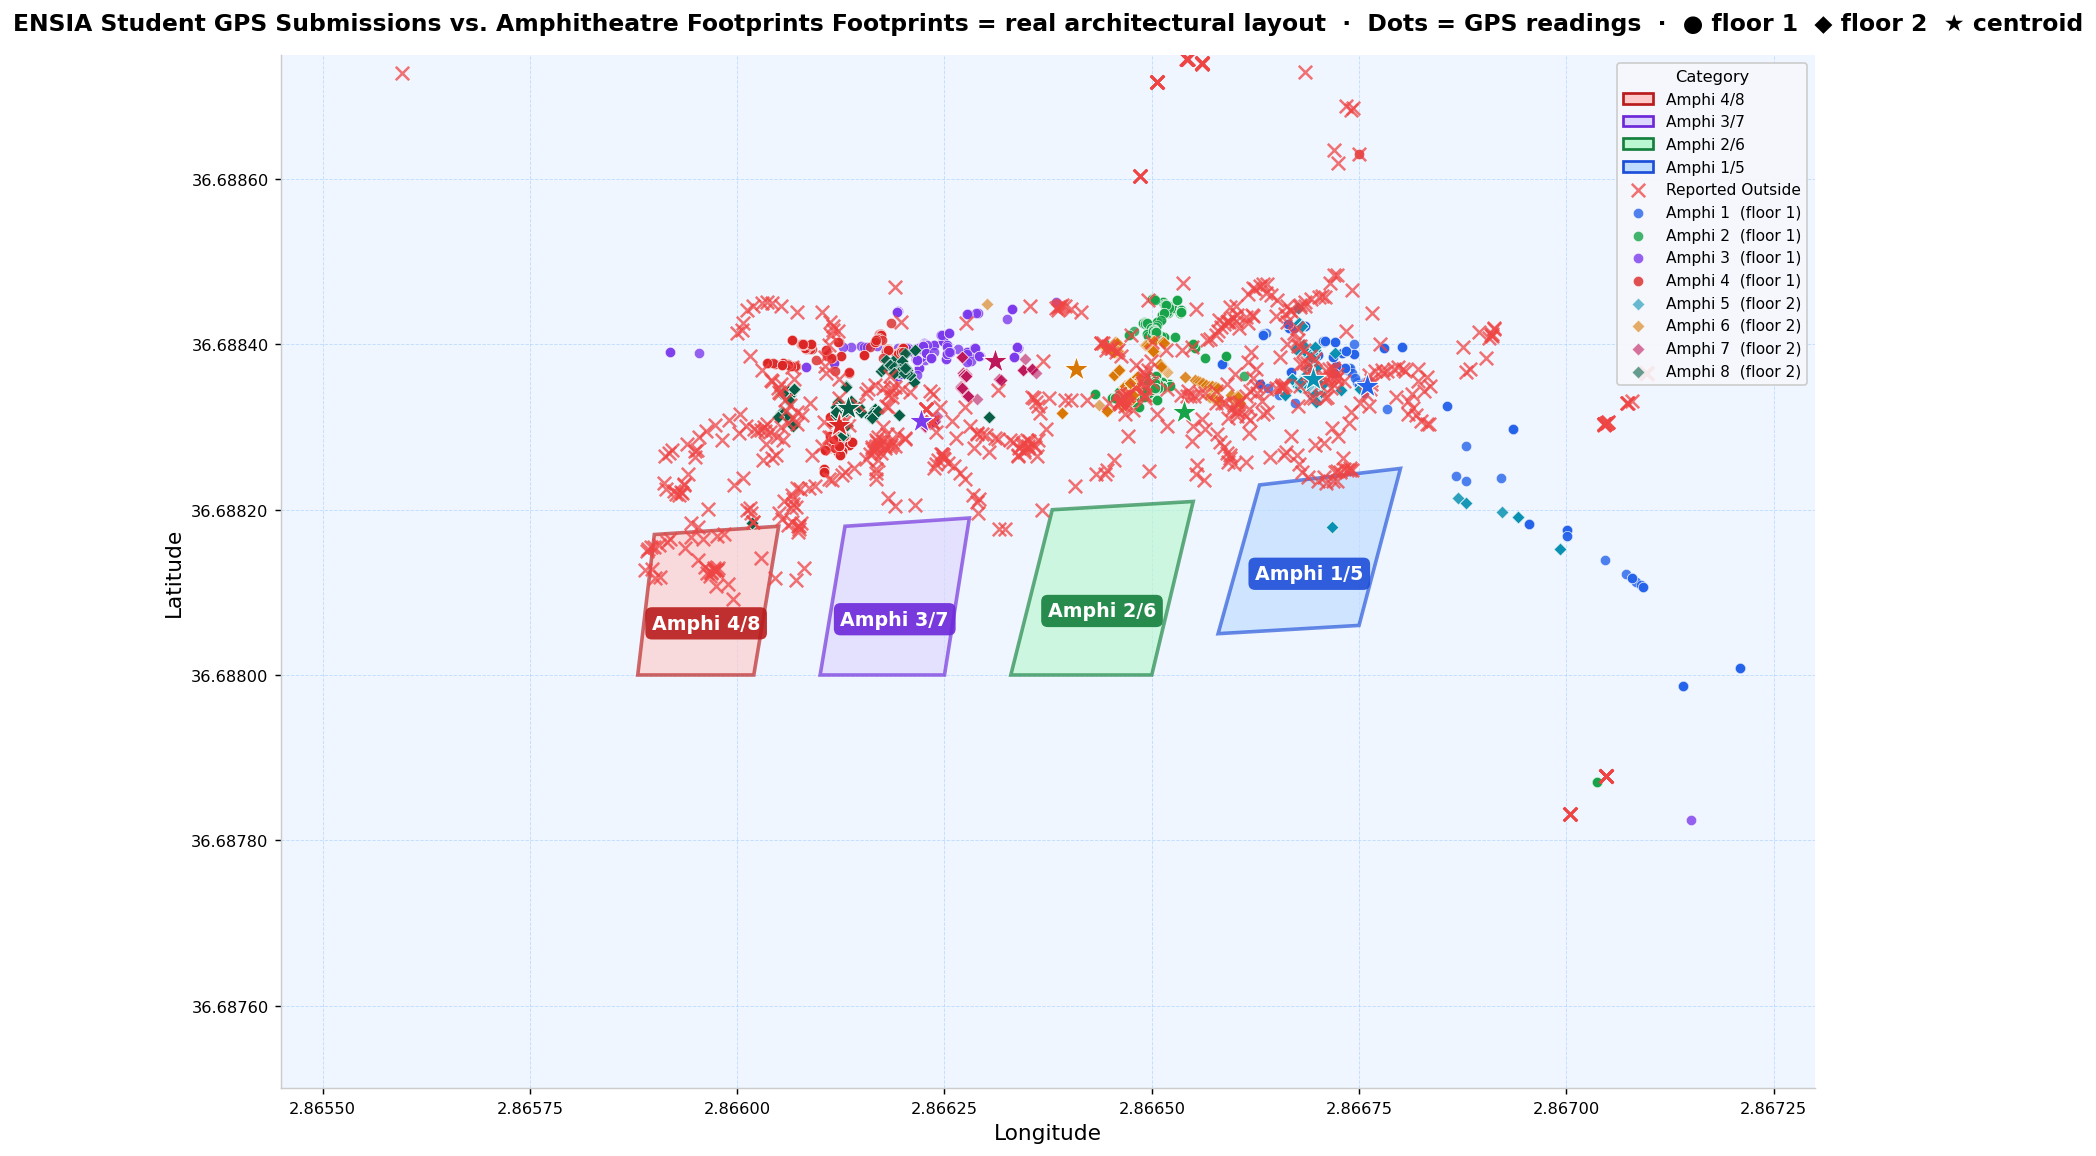

In [29]:
fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('#EFF6FF')   # light-blue sky feel

for name, pts in FOOTPRINTS.items():
    poly = MplPolygon(pts, closed=True,
                      facecolor=FP_FILL[name], edgecolor=FP_EDGE[name],
                      linewidth=2.0, alpha=0.65, zorder=2)
    ax.add_patch(poly)
    cx = pts[:, 0].mean()
    cy = pts[:, 1].mean() - 0.000025
    ax.text(cx, cy, name,
            ha='center', va='center', fontsize=10.5, fontweight='bold',
            color='white',
            bbox=dict(facecolor=FP_EDGE[name], edgecolor='none',
                      boxstyle='round,pad=0.35', alpha=0.90), zorder=6)


out_df = df[df['label'] == 'Outside']
ax.scatter(out_df['longitude_mean'], out_df['latitude_mean'],
           c='#EF4444', marker='x', s=55, linewidths=1.4,
           label='Reported Outside', zorder=4, alpha=0.75)

FLOOR = {f'Amphi {i}': 1 for i in range(1, 5)}
FLOOR.update({f'Amphi {i}': 2 for i in range(5, 9)})

for lbl in [f'Amphi {i}' for i in range(1, 9)]:
    sub = df[df['label'] == lbl]
    if sub.empty:
        continue
    mk    = 'o' if FLOOR[lbl] == 1 else 'D'
    size  = 32 if FLOOR[lbl] == 1 else 24
    alpha = 0.80 if FLOOR[lbl] == 1 else 0.60
    ax.scatter(sub['longitude_mean'], sub['latitude_mean'],
               c=GPS_COLOR_2D[lbl], marker=mk, s=size, alpha=alpha,
               label=f'{lbl}  (floor {FLOOR[lbl]})',
               edgecolors='white', linewidths=0.3, zorder=3)

for lbl, row in centroids.iterrows():
    ax.scatter(row['centroid_lon'], row['centroid_lat'],
               marker='*', s=220, c=GPS_COLOR_2D[lbl],
               edgecolors='white', linewidths=0.6, zorder=8)

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude',  fontsize=12)
ax.set_title('ENSIA Student GPS Submissions vs. Amphitheatre Footprints ' 'Footprints = real architectural layout  ·  Dots = GPS readings  ' '·  ● floor 1  ◆ floor 2  ★ centroid', fontsize=13, pad=14)
ax.set_xlim(2.86545, 2.86730)
ax.set_ylim(36.68750, 36.68875)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.5f'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.5f'))
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, color='#93C5FD')

fp_handles = [
    mpatches.Patch(facecolor=FP_FILL[n], edgecolor=FP_EDGE[n],
                   linewidth=1.5, label=n)
    for n in FOOTPRINTS
]
ax.legend(handles=fp_handles + ax.get_legend_handles_labels()[0],
          loc='upper right', fontsize=8.5, ncol=1,
          title='Category', title_fontsize=9)

plt.tight_layout()
plt.savefig('../results/amphi_footprints_2d.png', dpi=140, bbox_inches='tight')
plt.show()

## 10. 3D Building Model with GPS Overlay

This visualisation places the building in its real-world orientation:

- **X axis = Longitude** (East →)
- **Y axis = Latitude** (North ↑)
- **Z axis = Height** (Floor 1 at 0–4.5 m, Floor 2 at 4.5–9 m)

Floor 1 rooms sit on the ground plane (lat/lon). Floor 2 rooms are directly above them. GPS dots are projected onto their correct floor plane, making it immediately obvious that **latitude/longitude cannot distinguish the two floors** — they look identical from the top.

In [31]:
LAT0 = 36.68810        
LON0 = 2.86588        
M_PER_LAT = 111_320.0
M_PER_LON = 111_320.0 * np.cos(np.radians(LAT0))

def lonlat_to_xy(lon, lat):
    return (lon - LON0) * M_PER_LON, (lat - LAT0) * M_PER_LAT

def xy_to_lonlat(x, y):
    return LON0 + x / M_PER_LON, LAT0 + y / M_PER_LAT

FLOOR_H    = 4.5    # floor-to-floor height in metres
ROOM_W     = 14.0   # room width (East-West), matches ~0.00013° lon
ROOM_D     = 18.0   # room depth (North-South)
CORRIDOR_W = 2.0    # thin wall/corridor between rooms

ROOM_W_EDGES = np.array([0.0,
                          ROOM_W + CORRIDOR_W,
                          2*(ROOM_W + CORRIDOR_W),
                          3*(ROOM_W + CORRIDOR_W)])

FLOOR_ROOMS = {
    1: ['Amphi 4', 'Amphi 3', 'Amphi 2', 'Amphi 1'],
    2: ['Amphi 8', 'Amphi 7', 'Amphi 6', 'Amphi 5'],
}

ROOM_FACE_COLOR = {
    'Amphi 1': '#BFDBFE', 'Amphi 5': '#BFDBFE',
    'Amphi 2': '#BBF7D0', 'Amphi 6': '#BBF7D0',
    'Amphi 3': '#DDD6FE', 'Amphi 7': '#DDD6FE',
    'Amphi 4': '#FECACA', 'Amphi 8': '#FECACA',
}

def make_box_faces(x0, x1, y0, y1, z0, z1):
    
    return [
        [[x0,y0,z0],[x1,y0,z0],[x1,y1,z0],[x0,y1,z0]],
        [[x0,y0,z1],[x1,y0,z1],[x1,y1,z1],[x0,y1,z1]],
        [[x0,y0,z0],[x1,y0,z0],[x1,y0,z1],[x0,y0,z1]],
        [[x0,y1,z0],[x1,y1,z0],[x1,y1,z1],[x0,y1,z1]],
        [[x0,y0,z0],[x0,y1,z0],[x0,y1,z1],[x0,y0,z1]],
        [[x1,y0,z0],[x1,y1,z0],[x1,y1,z1],[x1,y0,z1]],
    ]

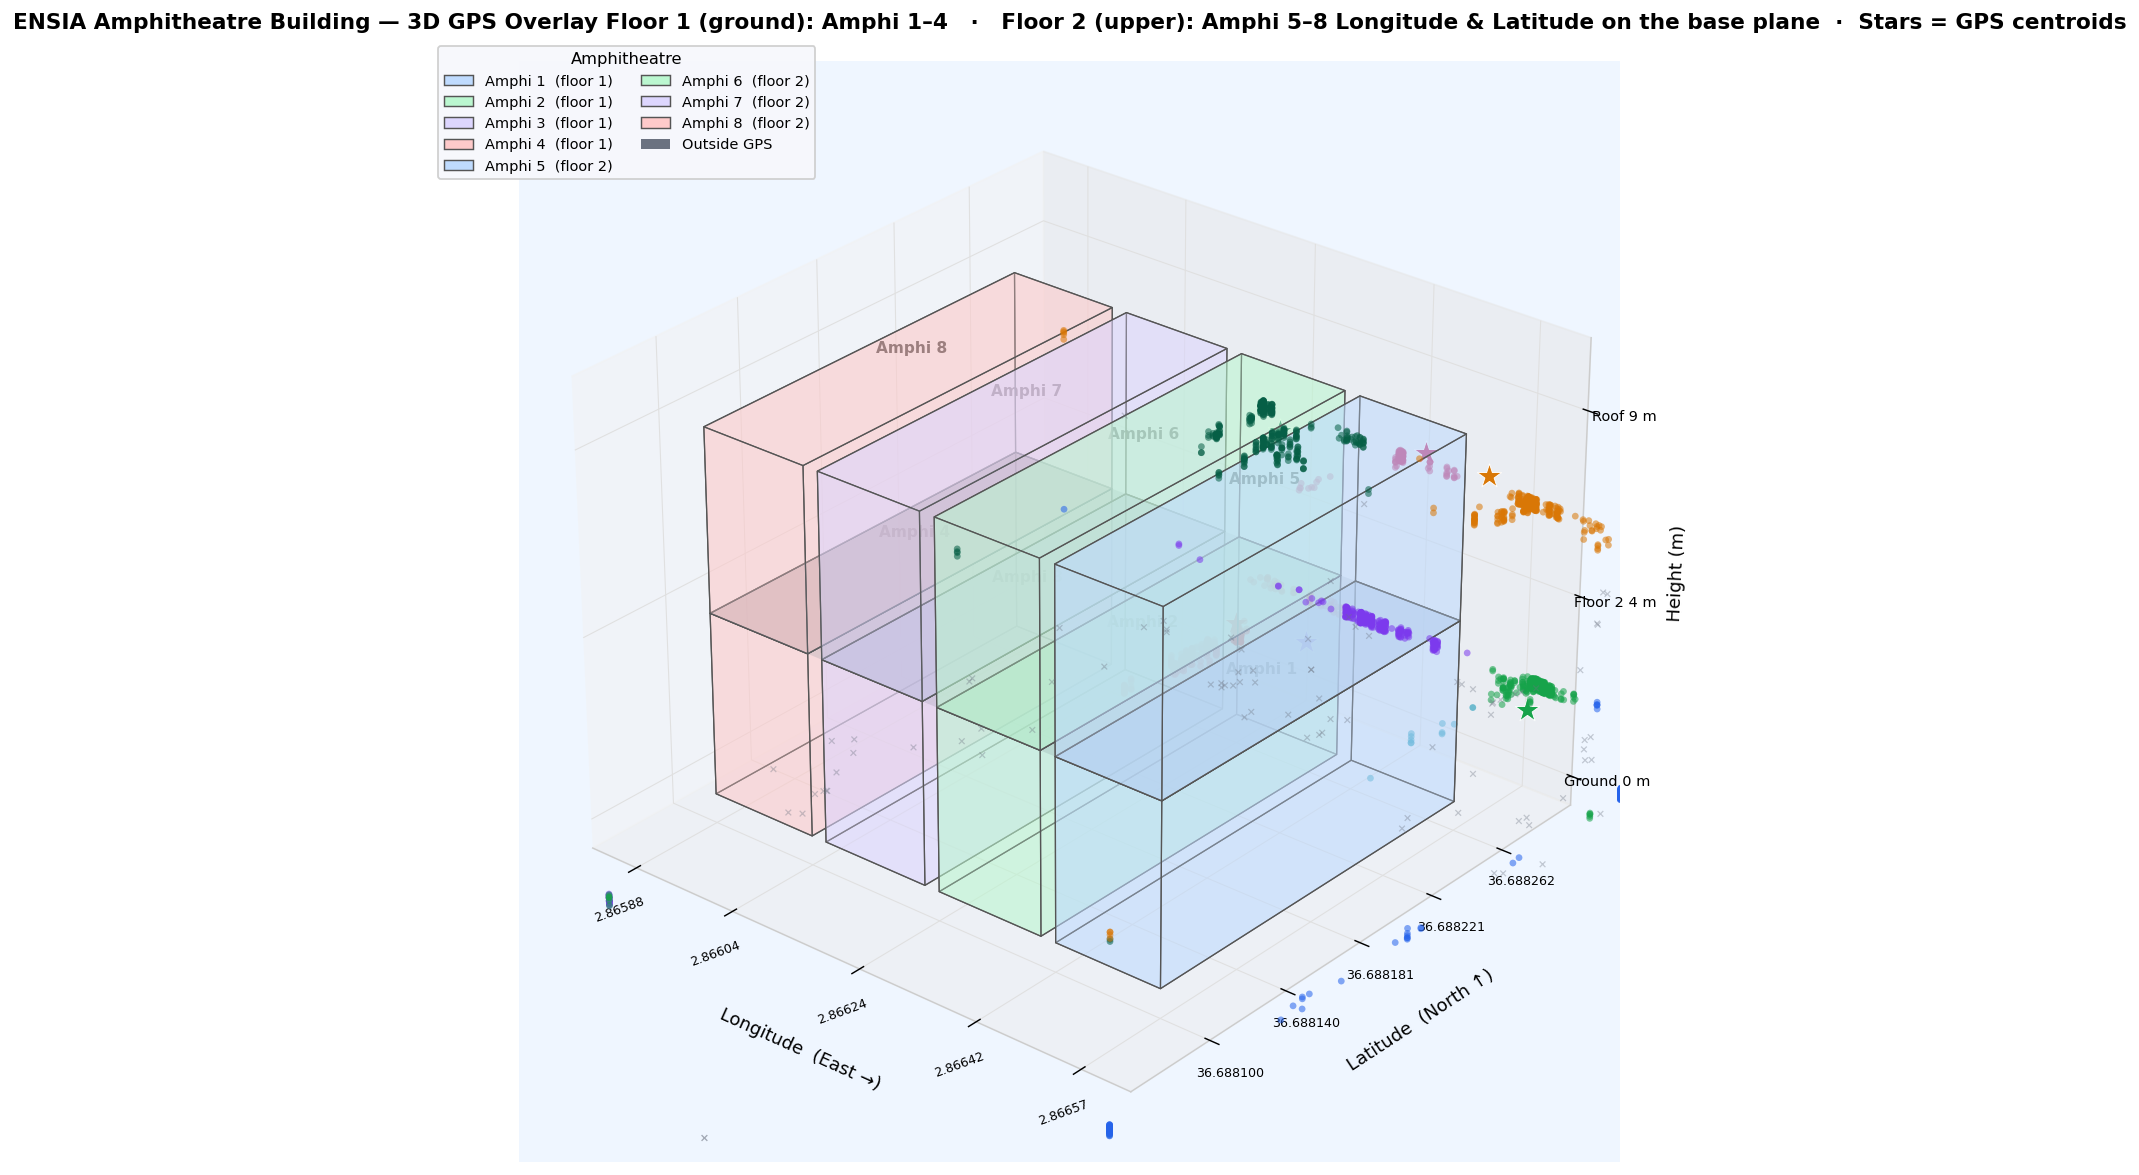

In [34]:
fig3d = plt.figure(figsize=(17, 11))
ax3   = fig3d.add_subplot(111, projection='3d')
fig3d.patch.set_facecolor('white')
ax3.set_facecolor('#EFF6FF')

for floor, rooms in FLOOR_ROOMS.items():
    z0 = (floor - 1) * FLOOR_H
    z1 = floor * FLOOR_H
    for col, rname in enumerate(rooms):
        x0_m = ROOM_W_EDGES[col]
        x1_m = x0_m + ROOM_W
        y0_m = 0.0
        y1_m = ROOM_D
        faces = make_box_faces(x0_m, x1_m, y0_m, y1_m, z0, z1)
        pc = Poly3DCollection(faces, zsort='average')
        pc.set_facecolor(ROOM_FACE_COLOR[rname])
        pc.set_edgecolor('#555555')
        pc.set_linewidth(0.7)
        pc.set_alpha(0.35)
        ax3.add_collection3d(pc)
        cx_m = (x0_m + x1_m) / 2
        cy_m = (y0_m + y1_m) / 2
        ax3.text(cx_m, cy_m, z1 + 0.25, rname,
                 ha='center', va='bottom', fontsize=8.5, fontweight='bold',
                 color='#1a1a1a', zorder=10)
        room_meta[rname] = (cx_m, cy_m, z0 + 0.05)

total_w = 4 * ROOM_W + 3 * CORRIDOR_W
xx_s, yy_s = np.meshgrid([0, total_w], [0, ROOM_D])
zz_s = np.full_like(xx_s, float(FLOOR_H))
ax3.plot_surface(xx_s, yy_s, zz_s, color='#94A3B8', alpha=0.18, zorder=1)

MAX_PTS = 350
rng3 = np.random.default_rng(99)

for lbl in [f'Amphi {i}' for i in range(1, 9)]:
    sub = df[df['label'] == lbl].copy()
    if sub.empty:
        continue
    cx_m, cy_m, z_fl = room_meta[lbl]

    gx, gy = lonlat_to_xy(sub['longitude_mean'].values,
                           sub['latitude_mean'].values)

    if len(gx) > MAX_PTS:
        idx = rng3.choice(len(gx), MAX_PTS, replace=False)
        gx, gy = gx[idx], gy[idx]

    gx_c = np.clip(gx, -ROOM_W,      total_w + ROOM_W)
    gy_c = np.clip(gy, -ROOM_D * 0.5, ROOM_D * 1.5)

    jitter = rng3.uniform(0.05, 0.35, len(gx_c))
    gz_plot = np.full(len(gx_c), z_fl) + jitter

    ax3.scatter(gx_c, gy_c, gz_plot,
                c=AMPHI_COLORS[lbl], s=14, alpha=0.55,
                edgecolors='none', depthshade=True, zorder=6)

    lon_c = centroids.loc[lbl, 'centroid_lon']
    lat_c = centroids.loc[lbl, 'centroid_lat']
    cx_gps, cy_gps = lonlat_to_xy(lon_c, lat_c)
    cx_gps = np.clip(cx_gps, -ROOM_W, total_w + ROOM_W)
    cy_gps = np.clip(cy_gps, -ROOM_D * 0.5, ROOM_D * 1.5)
    ax3.scatter([cx_gps], [cy_gps], [z_fl + 0.5],
                marker='*', s=200, c=AMPHI_COLORS[lbl],
                edgecolors='white', linewidths=0.5, zorder=10)

out3 = df[df['label'] == 'Outside']
if not out3.empty:
    ogx, ogy = lonlat_to_xy(out3['longitude_mean'].values,
                              out3['latitude_mean'].values)
    ogx = np.clip(ogx, -ROOM_W * 2, total_w + ROOM_W * 2)
    ogy = np.clip(ogy, -ROOM_D,     ROOM_D * 2)
    if len(ogx) > 200:
        idx = rng3.choice(len(ogx), 200, replace=False)
        ogx, ogy = ogx[idx], ogy[idx]
    ax3.scatter(ogx, ogy, np.full(len(ogx), -0.05),
                c='#6B7280', s=10, alpha=0.35, marker='x',
                linewidths=0.7, edgecolors='none', zorder=3)


x_tick_m   = np.array([0, ROOM_W, 2*(ROOM_W+CORRIDOR_W),
                        3*(ROOM_W+CORRIDOR_W), total_w])
lon_ticks   = [xy_to_lonlat(x, 0)[0] for x in x_tick_m]
ax3.set_xticks(x_tick_m)
ax3.set_xticklabels([f'{v:.5f}' for v in lon_ticks], fontsize=7, rotation=20)

y_tick_m   = np.linspace(0, ROOM_D, 5)
lat_ticks   = [xy_to_lonlat(0, y)[1] for y in y_tick_m]
ax3.set_yticks(y_tick_m)
ax3.set_yticklabels([f'{v:.6f}' for v in lat_ticks], fontsize=7)

ax3.set_zticks([0, FLOOR_H, 2 * FLOOR_H])
ax3.set_zticklabels(['Ground 0 m', f'Floor 2 {FLOOR_H:.0f} m', f'Roof {2*FLOOR_H:.0f} m'], fontsize=8)

ax3.set_xlabel('Longitude  (East →)', fontsize=10, labelpad=14)
ax3.set_ylabel('Latitude  (North ↑)', fontsize=10, labelpad=14)
ax3.set_zlabel('Height (m)',           fontsize=10, labelpad=10)

ax3.set_title(
    'ENSIA Amphitheatre Building — 3D GPS Overlay ' 'Floor 1 (ground): Amphi 1–4   ·   Floor 2 (upper): Amphi 5–8 ' 'Longitude & Latitude on the base plane  ·  Stars = GPS centroids', fontsize=12, pad=18)

ax3.view_init(elev=28, azim=-50)

ax3.set_xlim(-5, total_w + 5)
ax3.set_ylim(-4, ROOM_D + 4)
ax3.set_zlim(-0.5, 2 * FLOOR_H + 1.5)

handles = [
    mpatches.Patch(facecolor=ROOM_FACE_COLOR[f'Amphi {i}'],
                   edgecolor='#555555', linewidth=0.8,
                   label=f'Amphi {i}  (floor {1 if i<=4 else 2})')
    for i in range(1, 9)
]
handles.append(mpatches.Patch(facecolor='#6B7280', label='Outside GPS'))
ax3.legend(handles=handles, loc='upper left',
           bbox_to_anchor=(-0.08, 1.02), fontsize=8,
           framealpha=0.90, ncol=2, title='Amphitheatre', title_fontsize=9)

plt.tight_layout()
plt.savefig('../results/amphi_building_3d.png', dpi=140, bbox_inches='tight')
plt.show()

**What this 3D view reveals:**
- Each pair (Amphi 1 & 5, 2 & 6, 3 & 7, 4 & 8) occupies the **same horizontal footprint** — the GPS dots from both floors cluster at the same lat/lon.
- The two floors are physically stacked in Z (height), but GPS cannot detect height.
- This is the core difficulty: distinguishing Amphi 1 from Amphi 5 using only GPS requires indirect cues — accuracy, variance, or user-reported floor context.

## 11. EDA Summary & Next Steps

### Key findings

| Finding | Impact on modelling |
|---|---|
| Centroid pairs < 15 m apart (1/5, 2/6, 3/7, 4/8) | Raw lat/lon cannot separate these — must use engineered features |
| GPS accuracy median ≈ 20 m indoors | Accuracy itself is an informative feature |
| Amphi 8: 20 rows (v1) → ~999 rows (v2) | Class balance greatly improved; less need for oversampling |
| Amphi 7 still scarce (~122 rows) | Consider collecting more data or using class-weighted loss |
| Amphi 2 high variance | May benefit from outlier filter (remove readings > 3σ from centroid) |
| Floor pairs share GPS footprint | Floor disambiguation requires non-GPS features or user hint |

In [ ]:
# Moved to 02_preprocessing.ipynb as requested.
clean_path = '../data/processed/gps_data_clean.csv'
df_clean = pd.read_csv(clean_path)

# Use canonical cleaned label when available.
if 'target_label' in df_clean.columns:
    df_clean['label'] = df_clean['target_label']
elif 'label' not in df_clean.columns and 'amphitheatre' in df_clean.columns:
    df_clean['label'] = df_clean['amphitheatre']

centroids_clean = (
    df_clean[df_clean['label'].str.startswith('Amphi', na=False)]
    .groupby('label')[['latitude_mean', 'longitude_mean']]
    .mean()
    .rename(columns={'latitude_mean': 'centroid_lat', 'longitude_mean': 'centroid_lon'})
)

# ---------- Code 1 on cleaned data ----------
fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('#EFF6FF')

for name, pts in FOOTPRINTS.items():
    poly = MplPolygon(
        pts,
        closed=True,
        facecolor=FP_FILL[name],
        edgecolor=FP_EDGE[name],
        linewidth=2.0,
        alpha=0.65,
        zorder=2,
    )
    ax.add_patch(poly)
    cx = pts[:, 0].mean()
    cy = pts[:, 1].mean() - 0.000025
    ax.text(
        cx,
        cy,
        name,
        ha='center',
        va='center',
        fontsize=10.5,
        fontweight='bold',
        color='white',
        bbox=dict(facecolor=FP_EDGE[name], edgecolor='none', boxstyle='round,pad=0.35', alpha=0.90),
        zorder=6,
    )

out_df = df_clean[df_clean['label'] == 'Outside']
ax.scatter(
    out_df['longitude_mean'],
    out_df['latitude_mean'],
    c='#EF4444',
    marker='x',
    s=55,
    linewidths=1.4,
    label='Reported Outside (cleaned)',
    zorder=4,
    alpha=0.75,
)

FLOOR = {f'Amphi {i}': 1 for i in range(1, 5)}
FLOOR.update({f'Amphi {i}': 2 for i in range(5, 9)})

for lbl in [f'Amphi {i}' for i in range(1, 9)]:
    sub = df_clean[df_clean['label'] == lbl]
    if sub.empty:
        continue
    mk = 'o' if FLOOR[lbl] == 1 else 'D'
    size = 32 if FLOOR[lbl] == 1 else 24
    alpha = 0.80 if FLOOR[lbl] == 1 else 0.60
    ax.scatter(
        sub['longitude_mean'],
        sub['latitude_mean'],
        c=GPS_COLOR_2D[lbl],
        marker=mk,
        s=size,
        alpha=alpha,
        label=f'{lbl} (floor {FLOOR[lbl]})',
        edgecolors='white',
        linewidths=0.3,
        zorder=3,
    )

for lbl, row in centroids_clean.iterrows():
    ax.scatter(
        row['centroid_lon'],
        row['centroid_lat'],
        marker='*',
        s=220,
        c=GPS_COLOR_2D.get(lbl, '#111827'),
        edgecolors='white',
        linewidths=0.6,
        zorder=8,
    )

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title(
    'Cleaned GPS Submissions vs. Amphitheatre Footprints · ● floor 1  ◆ floor 2  ★ centroid',
    fontsize=13,
    pad=14,
)
ax.set_xlim(2.86545, 2.86730)
ax.set_ylim(36.68750, 36.68875)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.5f'))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.5f'))
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, color='#93C5FD')

fp_handles = [
    mpatches.Patch(facecolor=FP_FILL[n], edgecolor=FP_EDGE[n], linewidth=1.5, label=n)
    for n in FOOTPRINTS
]
ax.legend(
    handles=fp_handles + ax.get_legend_handles_labels()[0],
    loc='upper right',
    fontsize=8.5,
    ncol=1,
    title='Category',
    title_fontsize=9,
)

plt.tight_layout()
plt.savefig('../results/amphi_footprints_2d_cleaned.png', dpi=140, bbox_inches='tight')
plt.show()

# ---------- Code 2 on cleaned data ----------
label_order_amphi = [f'Amphi {i}' for i in range(1, 9)] + ['Outside']
cols = 3
rows_n = (len(label_order_amphi) + cols - 1) // cols

fig, axes = plt.subplots(rows_n, cols, figsize=(15, rows_n * 4.2))
axes = axes.flatten()

for i, lbl in enumerate(label_order_amphi):
    sub = df_clean[df_clean['label'] == lbl]
    c = AMPHI_COLORS.get(lbl, '#6B7280')
    axes[i].scatter(sub['longitude_mean'], sub['latitude_mean'], color=c, alpha=0.25, s=10, edgecolors='none')
    if lbl != 'Outside' and len(sub) > 15:
        try:
            sns.kdeplot(
                data=sub,
                x='longitude_mean',
                y='latitude_mean',
                fill=True,
                thresh=0.1,
                levels=4,
                color=c,
                alpha=0.35,
                ax=axes[i],
            )
        except Exception:
            pass
    if lbl in centroids_clean.index:
        axes[i].scatter(
            centroids_clean.loc[lbl, 'centroid_lon'],
            centroids_clean.loc[lbl, 'centroid_lat'],
            marker='*',
            s=220,
            color='black',
            zorder=6,
        )
    n_pts = len(sub)
    axes[i].set_title(f'{lbl} (n={n_pts:,})', fontsize=10, fontweight='semibold', color=c)
    axes[i].set_xlabel('Lon', fontsize=8)
    axes[i].set_ylabel('Lat', fontsize=8)
    axes[i].grid(True, alpha=0.4)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Cleaned GPS cloud per class — KDE + scatter | black star = centroid', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/gps_facets_cleaned.png', bbox_inches='tight')
plt.show()

print('Saved: ../results/amphi_footprints_2d_cleaned.png')
print('Saved: ../results/gps_facets_cleaned.png')